Dataset Loaded Successfully!

Dataset Shape: (891, 12)

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4890/1700148028.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4890/1700148028.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

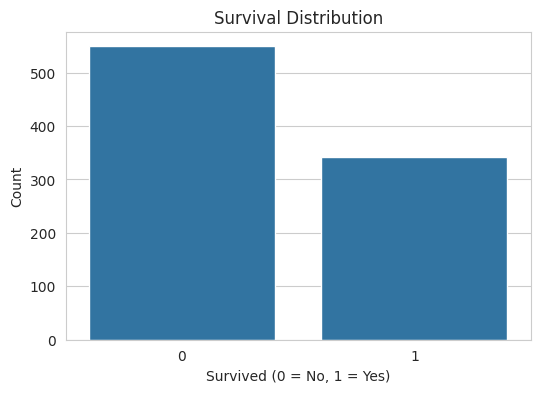

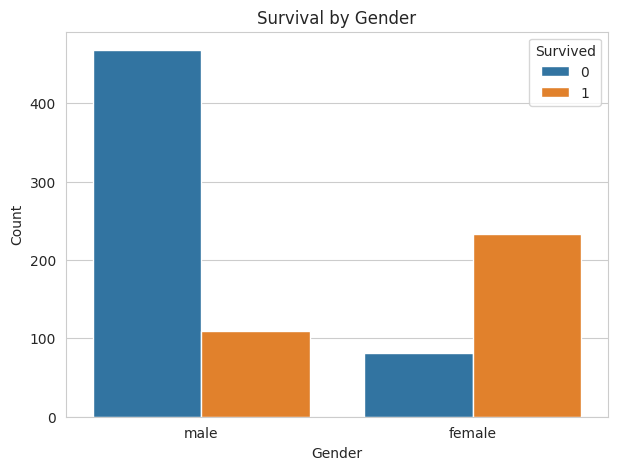

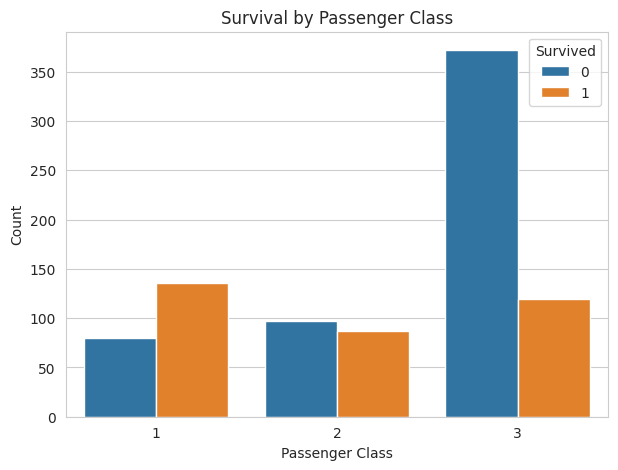

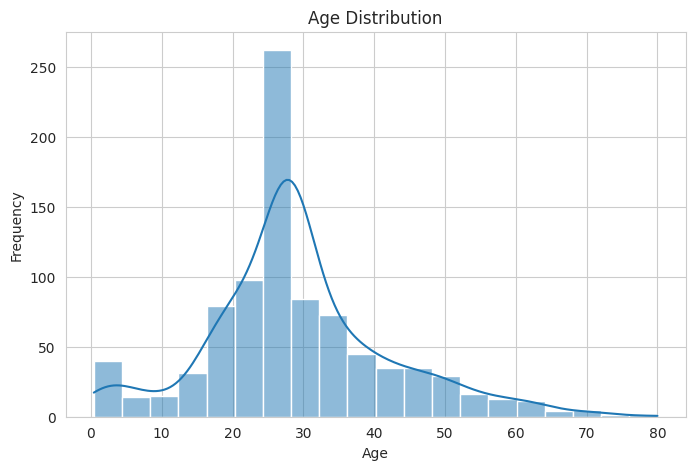

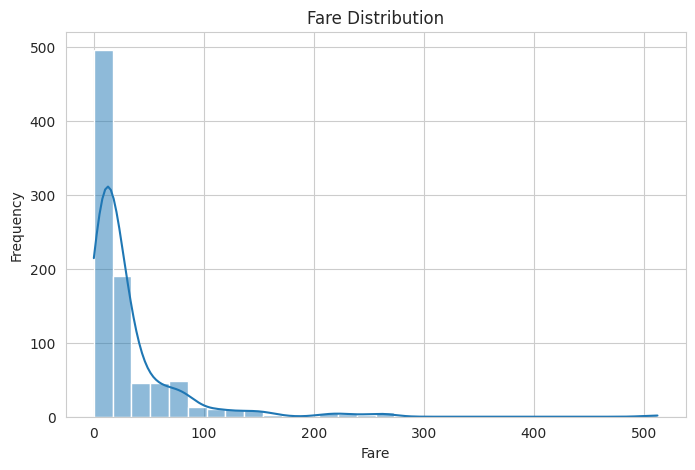

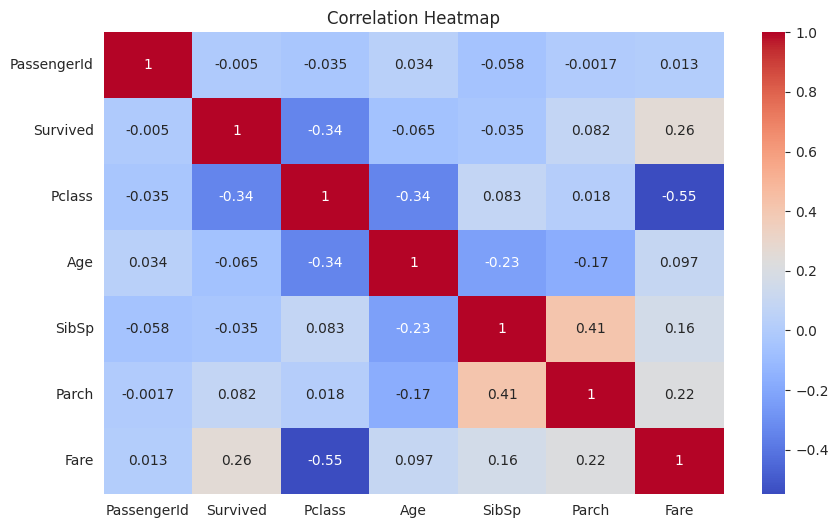

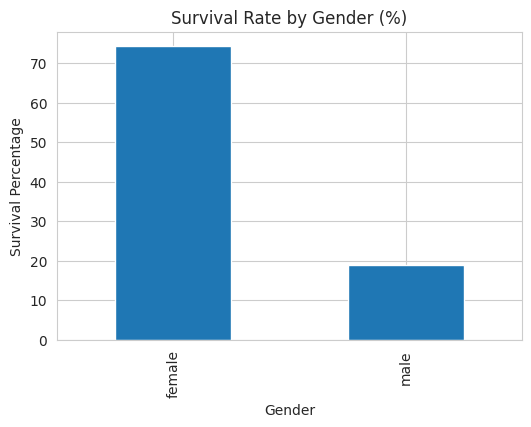

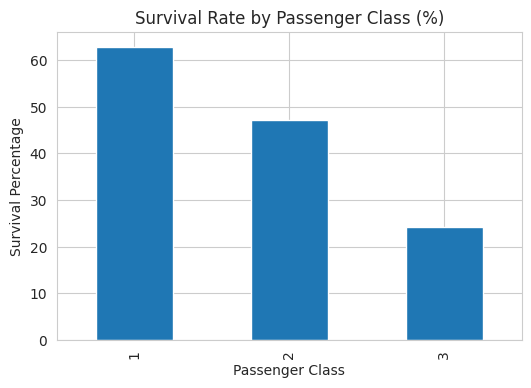


KEY INSIGHTS FROM THE ANALYSIS
1. Female passengers had a significantly higher survival rate than male passengers.
2. First-class passengers were more likely to survive.
3. Most passengers were between 20 and 40 years old.
4. Higher fare-paying passengers generally had better survival chances.
5. Missing values in Age and Embarked were handled during data cleaning.
6. The Cabin column was removed because it contained too many missing values.

EDA and Data Cleaning Completed Successfully!


In [2]:
# ==========================================
# PRODIGY INFOTECH - TASK 02
# Data Cleaning and Exploratory Data Analysis
# Titanic Dataset
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# Load Titanic Dataset Directly
# ==========================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

# ==========================================
# Missing Values Before Cleaning
# ==========================================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ==========================================
# Data Cleaning
# ==========================================

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column due to excessive missing values
df.drop('Cabin', axis=1, inplace=True)

# Rename Sex column to Gender
df.rename(columns={'Sex': 'Gender'}, inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# Survival Distribution
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# ==========================================
# Survival by Gender
# ==========================================

plt.figure(figsize=(7,5))
sns.countplot(x='Gender', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# ==========================================
# Survival by Passenger Class
# ==========================================

plt.figure(figsize=(7,5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# ==========================================
# Fare Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# ==========================================
# Correlation Heatmap
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ==========================================
# Survival Rate by Gender
# ==========================================

survival_gender = df.groupby('Gender')['Survived'].mean() * 100

plt.figure(figsize=(6,4))
survival_gender.plot(kind='bar')
plt.title('Survival Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Survival Percentage')
plt.show()

# ==========================================
# Survival Rate by Passenger Class
# ==========================================

survival_class = df.groupby('Pclass')['Survived'].mean() * 100

plt.figure(figsize=(6,4))
survival_class.plot(kind='bar')
plt.title('Survival Rate by Passenger Class (%)')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Percentage')
plt.show()

# ==========================================
# Final Insights
# ==========================================

print("\n==============================")
print("KEY INSIGHTS FROM THE ANALYSIS")
print("==============================")

print("1. Female passengers had a significantly higher survival rate than male passengers.")
print("2. First-class passengers were more likely to survive.")
print("3. Most passengers were between 20 and 40 years old.")
print("4. Higher fare-paying passengers generally had better survival chances.")
print("5. Missing values in Age and Embarked were handled during data cleaning.")
print("6. The Cabin column was removed because it contained too many missing values.")

print("\nEDA and Data Cleaning Completed Successfully!")